<div align="center">
  <h1><b> Quantum Information </b></h1>
  <h2> State Preparation </h2>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- [Introduction](#introduction)
- [Unitary Decomposition](#unitary-decomposition)
- [Qiskit Examples](#qiskit-examples)

# Introduction

Quantum state preparation consists of finding a unitary matrix $\hat{U}$ such that acting on an initial state $|0\rangle^{\otimes n} = [1,0,0,…,0]$ produces the intended target state $|\psi \rangle$. This operation can be represented by:

$$ |\psi \rangle = \hat{U} |0 \rangle^{\otimes n} = (\alpha_1, . . . , \alpha_N).$$

One possible choice for $\hat{U}$ is such that the first column of $\hat{U}$ corresponds to the state vector $∣\psi\rangle$, while the remaining columns are chosen in such a way as to make the matrix unitary:

$$ 
\hat{U} = \begin{bmatrix}
 \alpha_0 & * & * & \cdots \\
 \alpha_1 & * & * & \cdots \\
 \vdots   & \vdots & \vdots & \ddots \\
 \alpha_{2^{n-1}} & * & * & \cdots
\end{bmatrix}
$$

Implementation via quantum circuits requires this matrix to be decomposed into a sequence of unitary quantum gates that are available in the quantum hardware. For example, on the IBM platform, at the software level, the sequence of finite universal gates (Clifford+T) is ${H, S, CNOT, T}$. While the sequence of continuous universal gates is: ${R_x(\theta), R_y(\theta), R_z(\theta), P(\lambda), CNOT}$. However, fault-tolerant implementation of these gates must be accomplished with native hardware-level gates. IBM's native gates are: $CNOT, \sqrt{CNOT}, R_x(\theta), R_y(\theta), R_z(\theta)$.  

# Unitary Decomposition

A well-known decomposition for 1-qubit unitary matrices is the Z-Y decomposition (Ref [1], theorem 4.1, pg. 175):

\begin{equation}
\hat{U} = e^{i\alpha}R_z(\beta)R_y(\gamma)R_z(\delta).
\end{equation}

Where $\alpha$, $\beta$, $\gamma$ e $\delta$ are real numbers. The gate $R_y(\gamma)$ can be written as follows:

$$ R_y(\gamma) = SHR_z(\gamma)HSZ.$$

Therefore, the problem of approximating arbitrary quantum states reduces to the problem of finding good approximations of the gate $R_y(\gamma)$ through **algorithms** that vary the parameter $\gamma$.

Other algorithms exist for unitary gate decomposition. One of them is the algorithm `Quantum Shannon Decomposition` [2] which allows to decompose any unitary matrix into CNOT gates and single qubit gates. For a unitary $n$-qubit gate, this algorithm produces approximately $\frac{1}{2} 4^n$ CNOT gates. Another algorithm for decomposing a unitary matrix into CNOT and single-qubit gates is the decomposition `cosseno-seno (Cosine-Sine Decomposition)` [2].

For example, the Toffoli gate can be decomposed into H, S, CNOT, and T gates.

# Qiskit Examples

In Qiskit, when `state_vector` is passed, the quantum state is prepared based on the isometry synthesis described in [3]. 

Observe that `qc.initialize(state_vector, qubit)` is an instruction and not a quantum gate, since it contains a reset operation, which is not unitary.

In [2]:
from qiskit import QuantumCircuit
import numpy as np

- 1-qubit state:

$$ |\psi\rangle = \frac{1}{\sqrt 2}(|0\rangle + |1\rangle) =  \frac{1}{\sqrt 2} \begin{bmatrix} 1 \\1 \end{bmatrix}$$

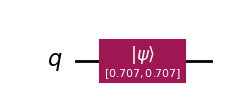

In [3]:
# Target state:
state_vector = [1/np.sqrt(2), 1/np.sqrt(2)]  # |ψ⟩ = (|0⟩ + |1⟩)/√2

# Creating a quantum circuit with 1 qubit:
qc = QuantumCircuit(1)

# Initializing the state:
qc.initialize(state_vector, 0)

qc.draw(output='mpl')  

- 2-qubit state:

$$ |\psi\rangle = \frac{1}{\sqrt 2}(|00\rangle + |01\rangle) = \frac{1}{\sqrt 2} \begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix} + \frac{1}{\sqrt 2} \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix} = \frac{1}{\sqrt 2} \begin{bmatrix} 1 \\ 1 \\ 0 \\ 0 \end{bmatrix}$$

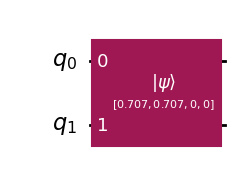

In [4]:
# Target state:
state_vector = [1/np.sqrt(2), 1/np.sqrt(2), 0, 0]  # (|00⟩ + |01⟩)/√2

# Creating a quantum circuit with 2 qubits:
qc = QuantumCircuit(2)

# Initializing the state:
qc.initialize(state_vector, [0, 1])

qc.draw(output='mpl')  

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed. 

[2] V. Shende, S. S. Bullock, and I. Markov, "Synthesis of quantum logic circuits," Computer-Aided Design of Integrated Circuits and Systems, IEEE Transactions on, vol. 25, pp. 1000 – 1010, July 2006.

[3] Iten et al., Quantum circuits for isometries (2016). Phys. Rev. A 93, 032318.